In [10]:
import pandas as pd
import matplotlib.pyplot as plt

theory = pd.read_csv("../data/cycle_theory.csv")
simulation = pd.read_csv("../data/cycle_simulation.csv")

In [11]:
stats = simulation.groupby("cycle_length")["absorption_time"].agg(
    simulation_mean="mean",
    simulation_variance="var"
).reset_index()

In [12]:
theory = theory.rename(columns={
    "mean_absorption_time": "theory_mean",
    "variance": "theory_variance"
})

results = theory.merge(stats, on="cycle_length")

results

,cycle_length,initial_state,theory_mean,theory_variance,prob_cheese,prob_cat,simulation_mean,simulation_variance
0,3,3,18.0,258.0,0.5,0.5,17.9465,259.469185
1,4,3,21.0,392.0,0.5,0.5,20.9270,391.216593
2,5,3,24.0,568.0,0.5,0.5,24.3239,581.776766
3,6,3,27.0,792.0,0.5,0.5,27.3426,833.341559
4,7,3,30.0,1070.0,0.5,0.5,30.1303,1116.876610
5,8,3,33.0,1408.0,0.5,0.5,33.1196,1367.560052
6,9,3,36.0,1812.0,0.5,0.5,36.3077,1800.029224
7,10,3,39.0,2288.0,0.5,0.5,39.5132,2397.440370
8,11,3,42.0,2842.0,0.5,0.5,42.3697,2879.685390
9,12,3,45.0,3480.0,0.5,0.5,45.5552,3486.988452


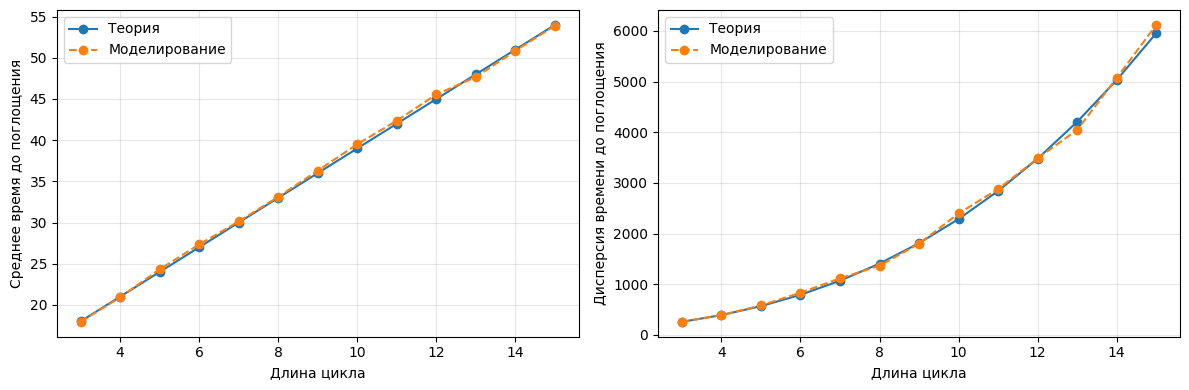

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    results["cycle_length"],
    results["theory_mean"],
    "o-",
    label="Теория"
)

axes[0].plot(
    results["cycle_length"],
    results["simulation_mean"],
    "o--",
    label="Моделирование"
)

axes[0].set_xlabel("Длина цикла")
axes[0].set_ylabel("Среднее время до поглощения")
axes[0].legend()
axes[0].grid(alpha=0.3)



axes[1].plot(
    results["cycle_length"],
    results["theory_variance"],
    "o-",
    label="Теория"
)

axes[1].plot(
    results["cycle_length"],
    results["simulation_variance"],
    "o--",
    label="Моделирование"
)

axes[1].set_xlabel("Длина цикла")
axes[1].set_ylabel("Дисперсия времени до поглощения")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../plots/cycle_experiment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()